<a href="https://colab.research.google.com/github/Tassigulias/Aulas-SCTEC/blob/master/desafio_extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files

uploaded = files.upload()

Saving sample_superstore.csv to sample_superstore (2).csv


In [4]:
import pandas as pd

df = pd.read_csv('sample_superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [5]:
print(df.head())

print(df.info())

print(df.dtypes)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]
0
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9

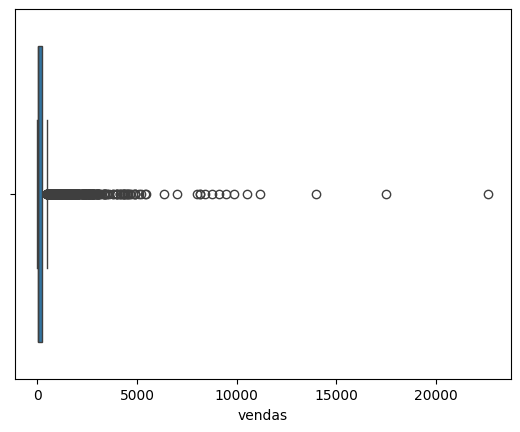

         vendas
2697  22638.480
6826  17499.950
8153  13999.960
2623  11199.968
4190  10499.970


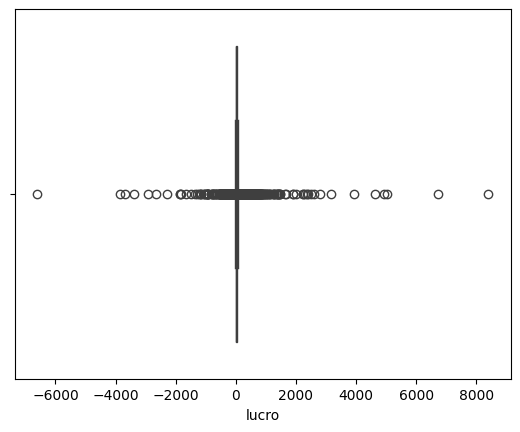

          lucro
6826  8399.9760
8153  6719.9808
4190  5039.9856
9039  4946.3700
4098  4630.4755
          lucro
7772 -6599.9780
683  -3839.9904
9774 -3701.8928
3011 -3399.9800
4991 -2929.4845


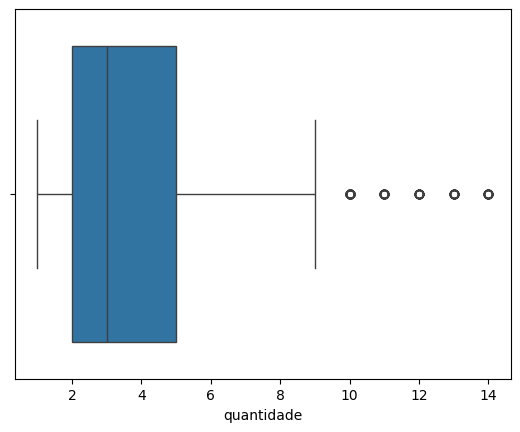

In [9]:
#identificando linhas duplicadas:
duplicateRows = df[df.duplicated()]
print(duplicateRows) #observei que não existem linhas totalmente duplicadas: Index: [].

#identificando itens duplicados:
duplicateRows = df[df.duplicated()]
print(len(duplicateRows)) #printou 0, o que significa que não temos itens duplicados.

#verificacao de valores nulos
print(df.isnull().sum()) #o print obtido mostra que não há valores nulos na tabela.

#conversão dos tipos de dados:
#convertendo datas:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print(df[['Order Date', 'Ship Date']].dtypes)

#convertendo números que possam estar como texto:
print(df['Sales'].dtype) #não precisou converter pois já estava como float64

#verificando conversões:
print(df.info())

#renomeando colunas:
df = df.rename(columns={
    'Row ID': 'coluna',
    'Order ID': 'numero_do_pedido',
    'Order Date': 'data_do_pedido',
    'Ship Date': 'data_do_envio',
    'Ship Mode': 'forma_de_entrega',
    'Customer ID': 'codigo_do_cliente',
    'Customer Name': 'nome_do_cliente',
    'Segment': 'seguimento',
    'Country': 'pais',
    'City': 'cidade',
    'State': 'estado',
    'Postal Code': 'cep',
    'Region': 'regiao',
    'Product ID': 'codigo_do_produto',
    'Category': 'categoria',
    'Sub-Category': 'sub_categoria',
    'Product Name': 'produto',
    'Sales': 'vendas',
    'Quantity': 'quantidade',
    'Discount': 'desconto',
    'Profit': 'lucro'
    })
print(df.head()) #para ver a modificação dos nomes das colunas

#identificando outliers na coluna vendas:
sns.boxplot(x=df['vendas'])
plt.show() #encontrados 3 outliers
#analisando as maiores vendas:
print(df[['vendas']]
    .sort_values('vendas', ascending=False)
    .head(5))
#opto por manter os outliers por serem vendas possíveis, apesar de raras.

#identificando outliers na coluna lucro:
sns.boxplot(x=df['lucro'])
plt.show() #encontrados 3 outliers
#analisando os maiores lucros:
print(df[['lucro']]
    .sort_values('lucro', ascending=False)
    .head(5))
#opto por manter os outliers positivos por serem resultados das grandes vendas efetuadas.
print(df[['lucro']]
    .sort_values('lucro')
    .head(5))
#opto por manter os outliers negativos para serem apresentados como possíveis problemas na área financeira e/ou de planejamento da empresa.

#identificando outliers na coluna quantidade:
sns.boxplot(x=df['quantidade'])
plt.show() #encontrados 5 outliers
# opto por manter os outliers, considerando vendas possíveis.

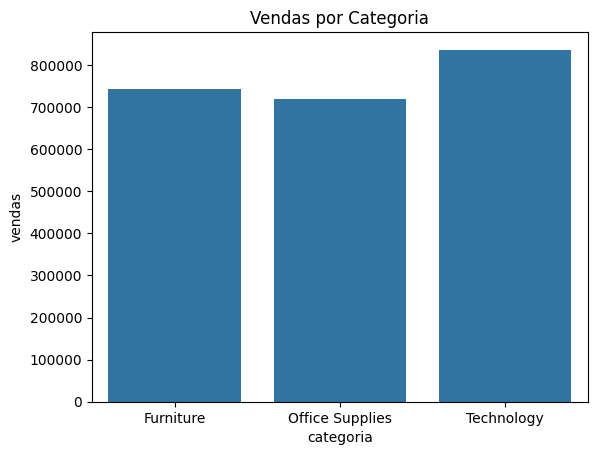

In [11]:
df.groupby('vendas')['categoria'].sum().reset_index()
vendas_categoria = (
    df.groupby('categoria')['vendas']
      .sum()
      .reset_index())

sns.barplot(data=vendas_categoria,
            x='categoria',
            y='vendas')

plt.title('Vendas por Categoria')
plt.show()

Nessa primeira análise, conseguimos visualizar que os produtos mais vendidos são itens de tecnologia, seguimos por mobília e suplementos de escritório.

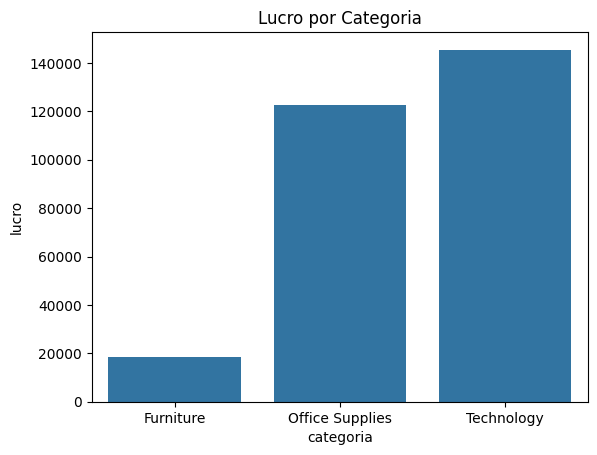

In [12]:
df.groupby('lucro')['categoria'].sum().reset_index()
vendas_categoria = (
    df.groupby('categoria')['lucro']
      .sum()
      .reset_index())

sns.barplot(data=vendas_categoria,
            x='categoria',
            y='lucro')

plt.title('Lucro por Categoria')
plt.show()

Observando as categorias que mais apresentam lucro à loja, em primeiro lugar estão os itens de tecnologia, porém a mobília apesar de ser a segunda categoria mais vendida, perde em lucro para os suplementos de escritório.
Seria interessante propor à empresa uma pesquisa de mercado frente aos concorrentes para analisar um possível aumento de preços da mobília, já que é a segunda categoria mais vendida porém a terceira em lucro.

In [13]:
!pip install plotly

In [20]:
df['estado'] = df['estado'].str.strip()

In [21]:
import us

df['state_code'] = df['estado'].apply(
    lambda x: us.states.lookup(x).abbr if us.states.lookup(x) else None)

In [22]:
import plotly.express as px

vendas_estado = df.groupby('state_code')['vendas'].sum().reset_index()

fig = px.choropleth(
    vendas_estado,
    locations='state_code',
    locationmode='USA-states',
    color='vendas',
    color_continuous_scale='Greens',
    title='Vendas por Estado'
)

fig.show()

lucro_estado = df.groupby('state_code')['lucro'].sum().reset_index()

fig = px.choropleth(
    lucro_estado,
    locations='state_code',
    locationmode='USA-states',
    color='lucro',
    color_continuous_scale='Greens',
    title='Lucro por Estado'
)

fig.show()

A análise geográfica em relação às vendas e ao lucro demonstra que o estado da Califórnia é o que mais gastou e onde a empresa mais obteve lucro, seguido de Nova Iorque, com o lucro próximo da Califórnia e Washington.

<Axes: xlabel='vendas', ylabel='lucro'>

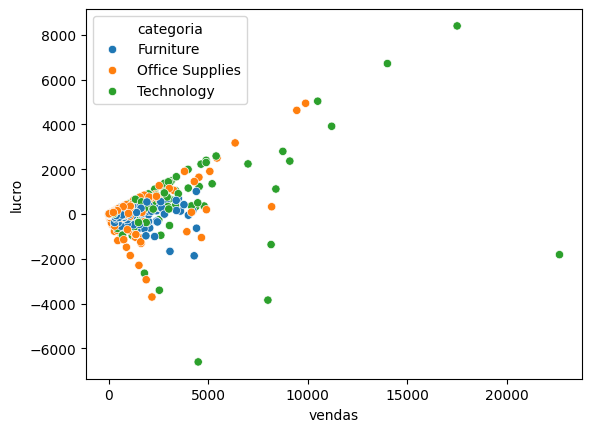

In [10]:
sns.scatterplot(
    data=df,
    x='vendas',
    y='lucro',
    hue='categoria'
) # Re-executing this cell after df has been defined.

No gráfico de dispersão, podemos observar que algumas vendas deram prejuízo (pontos abaixo do 0), isso significa desconto muito alto no produto ou preço cobrado muito baixo. E que a categoria não influencia, pois temos cores distintas na área plotada.

<Axes: xlabel='data_do_pedido'>

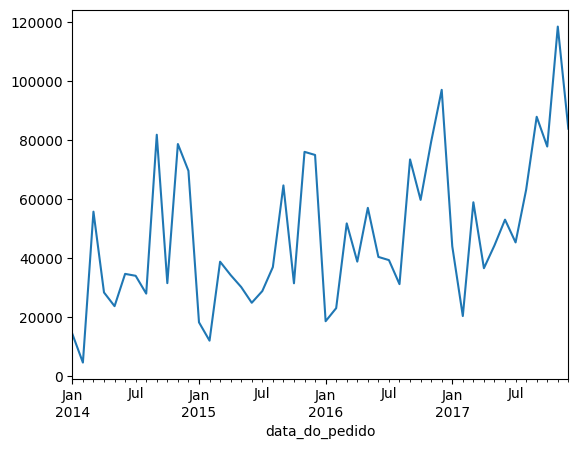

In [23]:
df['data_do_pedido'] = pd.to_datetime(df['data_do_pedido'])

vendas_por_mes = df.resample('ME', on='data_do_pedido')['vendas'].sum()

vendas_por_mes.plot()

Analisando as vendas por mês, observamos uma diminuição das vendas entre janeiro e fevereiro assim como setembro e outubro, esse último período podendo ser explicado pela proximidade da BlackFriday, já que em novembro as vendas voltam a subir.

In [ ]:
df.to_csv('superstore_tratado.csv', index=False)

In [ ]:
from google.colab import files

files.download('superstore_tratado.csv')